# Implementation of XOR using Multi-Layer Perceptron

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
# plot settings
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 15
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['savefig.dpi'] = 600

In [2]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])
y = np.array([[0],
              [1],
              [1],
              [0]])

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [10]:
def initialize_network():
    # Xavier initialization: scale weights by sqrt(2 / fan_in + fan_out)
    # This prevents vanishing/exploding gradients and breaks symmetry reliably.

    W1 = np.random.randn(2, 4) * np.sqrt(2.0 / (2 + 4))
    b1 = np.zeros((1, 4))

    W2 = np.random.randn(4, 1) * np.sqrt(2.0 / (4 + 1))
    b2 = np.zeros((1, 1))

    return W1, b1, W2, b2

In [5]:
def forward(X, W1, b1, W2, b2):

    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)

    output_input = np.dot(hidden_output, W2) + b2
    predicted = sigmoid(output_input)

    return hidden_output, predicted

In [6]:
def backward(X, y,
             hidden_output,
             predicted,
             W2,
             learning_rate):

    output_error = y - predicted
    output_delta = output_error * sigmoid_derivative(predicted)

    hidden_error = output_delta.dot(W2.T)
    hidden_delta = hidden_error * sigmoid_derivative(hidden_output)

    dW2 = hidden_output.T.dot(output_delta)
    db2 = np.sum(output_delta, axis=0, keepdims=True)

    dW1 = X.T.dot(hidden_delta)
    db1 = np.sum(hidden_delta, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

In [7]:
important_updates = [
    1, 2, 3, 50, 100,
    200, 500, 1000,
    2000, 5000
]

In [8]:
def train_mlp(X, y,
              learning_rate=0.5,
              epochs=10000,
              tolerance=1e-3):

    # Initialize network
    W1, b1, W2, b2 = initialize_network()

    losses = []
    accuracies = []
    snapshots = {}

    # Initial network: before any update
    hidden_output, predicted = forward(
        X, W1, b1, W2, b2
    )
    loss = np.mean((y - predicted) ** 2)
    predicted_class = (predicted >= 0.5).astype(int)
    accuracy = np.mean(predicted_class == y)
    losses.append(loss)
    accuracies.append(accuracy)

    snapshots[0] = (
        W1.copy(),
        b1.copy(),
        W2.copy(),
        b2.copy(),
        0
    )

    # Training loop
    for epoch in range(1, epochs + 1):

        # Forward propagation
        hidden_output, predicted = forward(
            X, W1, b1, W2, b2
        )
        # Backpropagation
        dW1, db1, dW2, db2 = backward(
            X,
            y,
            hidden_output,
            predicted,
            W2,
            learning_rate
        )

        # WEIGHT UPDATE
        W1 += learning_rate * dW1
        b1 += learning_rate * db1

        W2 += learning_rate * dW2
        b2 += learning_rate * db2

        # Forward propagation AFTER update
        hidden_output, predicted = forward(
            X, W1, b1, W2, b2
        )

        # Calculate MSE
        loss = np.mean(
            (y - predicted) ** 2
        )

        losses.append(loss)

        # Calculate accuracy
        predicted_class = (
            predicted >= 0.5
        ).astype(int)

        accuracy = np.mean(
            predicted_class == y
        )

        accuracies.append(accuracy)

        # save network after each update
        snapshots[epoch] = (
            W1.copy(),
            b1.copy(),
            W2.copy(),
            b2.copy(),
            epoch
        )

        # Print for important epochs
        if epoch in important_updates or accuracy == 1.0:

            print(f"\nEpoch: {epoch}")
            print(f"MSE: {loss:.6f}")
            print(f"Accuracy: {accuracy * 100:.1f}%")

            print("\nPredictions:")

            for i in range(len(X)):

                print(
                    f"Input = {X[i]}   "
                    f"Target = {y[i,0]:.0f}   "
                    f"Prediction = {predicted[i,0]:.4f}   "
                    f"Class = {predicted_class[i,0]}"
                )

            print(f"\nW1:{np.round(W1, 4)}")
            print(f"b1:{np.round(b1, 4)}")
            print(f"W2:{np.round(W2, 4)}")
            print(f"b2:{np.round(b2, 4)}")

        # convergence criterion
        if accuracy == 1.0 and loss < tolerance:
            important_updates.append(epoch-1)
            important_updates.append(epoch)
            print(f"XOR converged at epoch {epoch}")
            break
    # If convergence was not reached
    if accuracy != 1.0:
        print()
        print(f"Did not reach 100% accuracy within {epochs} updates.")
        print(f"Final accuracy : {accuracy * 100:.1f}%")
        print(f"Final MSE      : {loss:.8f}")

    return (
        W1,
        b1,
        W2,
        b2,
        losses,
        accuracies,
        snapshots
    )

In [11]:
W1, b1, W2, b2, losses, accuracies, snapshots = train_mlp(
    X,
    y,
    learning_rate=0.5,
    epochs=10000,
    tolerance=1e-3
)

Streaming output truncated to the last 5000 lines.
 [-0.5889]]
b2:[[-2.0617]]

Epoch: 3162
MSE: 0.001117
Accuracy: 100.0%

Predictions:
Input = [0 0]   Target = 0   Prediction = 0.0169   Class = 0
Input = [0 1]   Target = 1   Prediction = 0.9676   Class = 1
Input = [1 0]   Target = 1   Prediction = 0.9648   Class = 1
Input = [1 1]   Target = 0   Prediction = 0.0435   Class = 0

W1:[[ 5.5819 -5.9729 -2.5872  0.1287]
 [ 5.3784  3.7487  5.665   0.6143]]
b1:[[-1.529  -1.3929  0.3335 -0.1856]]
W2:[[ 6.4854]
 [ 7.6955]
 [-7.5834]
 [-0.5889]]
b2:[[-2.0617]]

Epoch: 3163
MSE: 0.001116
Accuracy: 100.0%

Predictions:
Input = [0 0]   Target = 0   Prediction = 0.0169   Class = 0
Input = [0 1]   Target = 1   Prediction = 0.9676   Class = 1
Input = [1 0]   Target = 1   Prediction = 0.9648   Class = 1
Input = [1 1]   Target = 0   Prediction = 0.0435   Class = 0

W1:[[ 5.5819 -5.973  -2.5874  0.1287]
 [ 5.3784  3.7489  5.6652  0.6144]]
b1:[[-1.529  -1.3929  0.3336 -0.1857]]
W2:[[ 6.4856]
 [ 7.6959]
 [

In [12]:
from matplotlib.lines import Line2D

def plot_decision_boundary(ax, X, y, W1, b1, W2, b2, title):

    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    _, output = forward(grid, W1, b1, W2, b2)

    Z = (output >= 0.5).astype(int)
    Z = Z.reshape(xx.shape)

    # Decision regions
    ax.contourf(
        xx,
        yy,
        Z,
        levels=[-0.5, 0.5, 1.5],
        cmap="coolwarm",
        alpha=0.35
    )

    # Training samples
    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=y.ravel(),
        cmap="coolwarm",
        edgecolors="black",
        s=120
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.set_xlabel("Input X1")
    ax.set_ylabel("Input X2")
    ax.set_title(title)
    ax.grid(True)

    # Legend
    cmap = plt.cm.coolwarm
    norm = plt.Normalize(vmin=0, vmax=1)

    legend_elements = [
        Line2D([0], [0],
            marker='o',
            color='w',
            label='Target = 0',
            markerfacecolor=cmap(norm(0)),
            markeredgecolor='black',
            markersize=10),

        Line2D([0], [0],
            marker='o',
            color='w',
            label='Target = 1',
            markerfacecolor=cmap(norm(1)),
            markeredgecolor='black',
            markersize=10)
    ]

    ax.legend(handles=legend_elements,
              loc='upper right',
              fontsize=11,frameon=True)

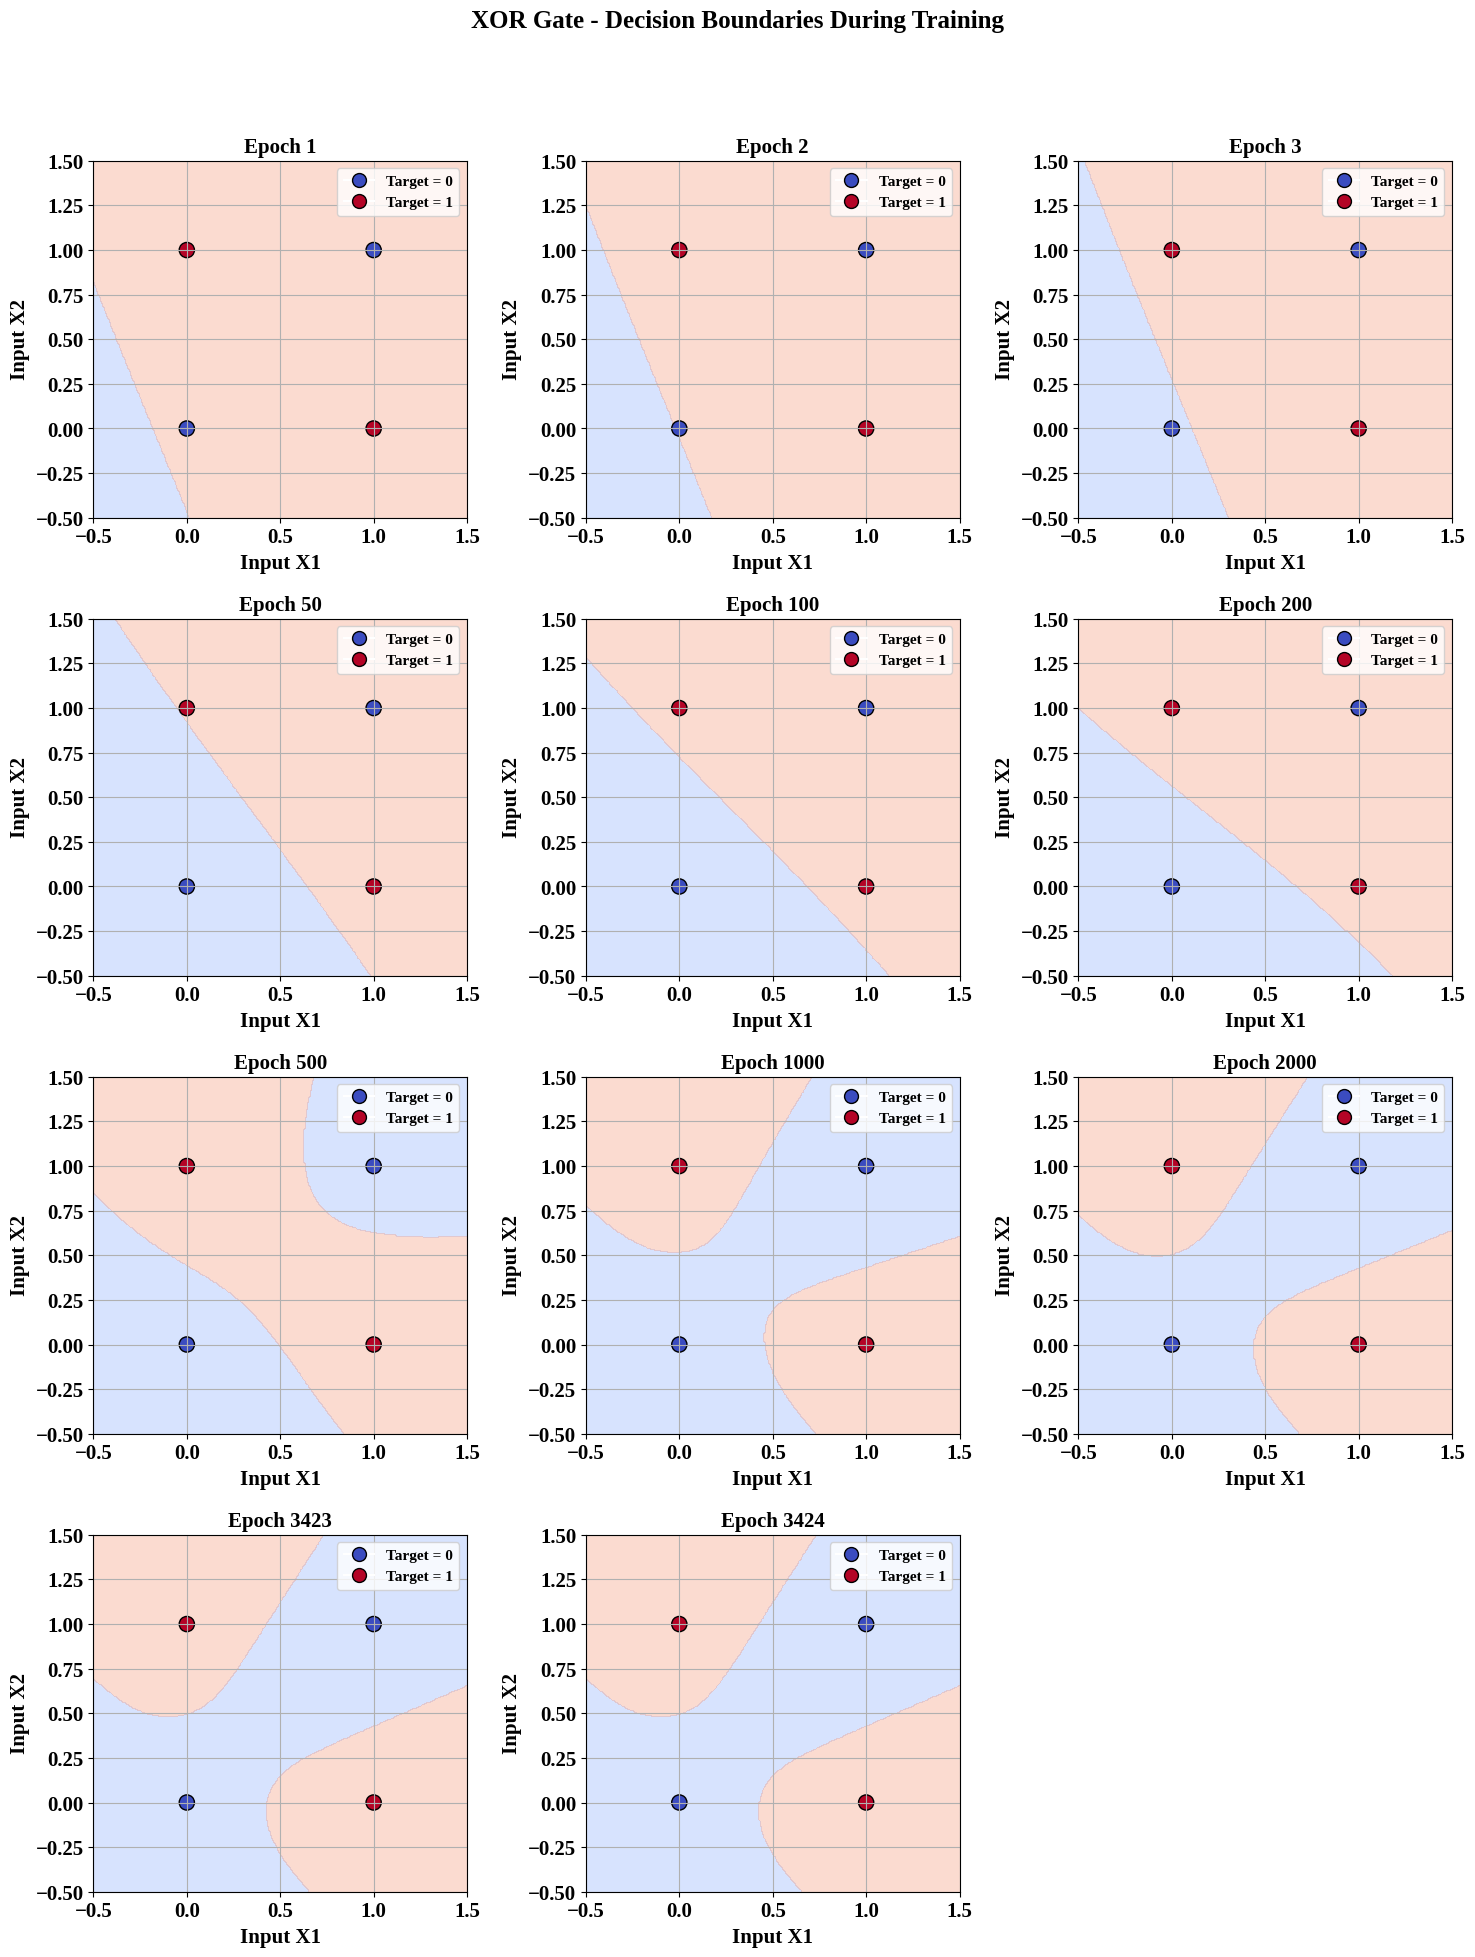

In [13]:
epochs_to_plot = sorted(
    [k for k in snapshots.keys() if isinstance(k, int) and k in important_updates]
)

if "final" in snapshots:
    epochs_to_plot.append("final")

cols = 3
rows = (len(epochs_to_plot) + cols - 1) // cols

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(5*cols, 5*rows)
)

axes = np.array(axes).reshape(-1)

fig.suptitle(
    "XOR Gate - Decision Boundaries During Training",
    fontsize=18,
    fontweight="bold"
)


for ax, ep in zip(axes, epochs_to_plot):

    W1, b1, W2, b2, epoch = snapshots[ep]

    if ep == "final":
        title = f"Final Converged\n(Epoch {epoch})"
    else:
        title = f"Epoch {epoch}"

    plot_decision_boundary(
        ax,
        X,
        y,
        W1,
        b1,
        W2,
        b2,
        title
    )


# Hide unused subplots
for ax in axes[len(epochs_to_plot):]:
    ax.axis("off")


plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "MLP_XOR.png",
    bbox_inches="tight"
)

plt.show()